# Exploratory Data Analysis of ogbl-biokg Dataset

In this notebook, we will load the ogbl-biokg dataset and perform some exploratory data analysis to understand its structure and contents.

In [1]:
from ogb.linkproppred import PygLinkPropPredDataset
import matplotlib.pyplot as plt
import networkx as nx

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Load the dataset
dataset = PygLinkPropPredDataset(name="ogbl-biokg")
split_edge = dataset.get_edge_split()
train_edge, valid_edge, test_edge = split_edge["train"], split_edge["valid"], split_edge["test"]
graph = dataset[0]  # pyg g

# Display basic information about the graph
print(f"Number of nodes: {graph.num_nodes}")
print(f"Number of edges: {graph.num_edges}")
# print(f"Number of features per node: {graph.x.shape[1]}")

c:\Users\wittd\anaconda3\envs\biokg_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Number of nodes: None
Number of edges: 0


c:\Users\wittd\anaconda3\envs\biokg_env\Lib\site-packages\torch_geometric\data\data.py:187: UserWarning: Unable to accurately infer 'num_nodes' from the attribute set '{'edge_index_dict', 'edge_reltype', 'num_nodes_dict'}'. Please explicitly set 'num_nodes' as an attribute of 'data' to suppress this warning
  return sum([v.num_nodes for v in self.node_stores])


In [9]:
import pickle
from ogb.linkproppred import PygLinkPropPredDataset

dataset = PygLinkPropPredDataset(name="ogbl-biokg")
# dataset[0]

with open("ogbl_biokg_raw.pkl", "wb") as f:
    pickle.dump(dataset[0], f)

In [10]:
with open("ogbl_biokg_raw.pkl", "rb") as f:
    data = pickle.load(f)
print(data)

Data(
  num_nodes_dict={
    disease=10687,
    drug=10533,
    function=45085,
    protein=17499,
    sideeffect=9969,
  },
  edge_index_dict={
    (disease, disease-protein, protein)=[2, 73547],
    (drug, drug-disease, disease)=[2, 5147],
    (drug, drug-drug_acquired_metabolic_disease, drug)=[2, 63430],
    (drug, drug-drug_bacterial_infectious_disease, drug)=[2, 18554],
    (drug, drug-drug_benign_neoplasm, drug)=[2, 30348],
    (drug, drug-drug_cancer, drug)=[2, 48514],
    (drug, drug-drug_cardiovascular_system_disease, drug)=[2, 94842],
    (drug, drug-drug_chromosomal_disease, drug)=[2, 316],
    (drug, drug-drug_cognitive_disorder, drug)=[2, 34660],
    (drug, drug-drug_cryptorchidism, drug)=[2, 128],
    (drug, drug-drug_developmental_disorder_of_mental_health, drug)=[2, 14314],
    (drug, drug-drug_endocrine_system_disease, drug)=[2, 55994],
    (drug, drug-drug_fungal_infectious_disease, drug)=[2, 36114],
    (drug, drug-drug_gastrointestinal_system_disease, drug)=[2, 8321

In [2]:
print(f"Total number of nodes: {graph.num_nodes}")
print(f"Total number of edges: {graph.num_edges}")
print(f"Node types and counts: {graph.num_nodes_dict}")
print(f"Edge types and counts: {[(k, v.shape[1]) for k, v in graph.edge_index_dict.items()]}")
# print(f"Number of features per node: {graph.x_dict}")  # Assuming features are in x_dict for heterogeneous graphs


Total number of nodes: None
Total number of edges: 0
Node types and counts: {'disease': 10687, 'drug': 10533, 'function': 45085, 'protein': 17499, 'sideeffect': 9969}
Edge types and counts: [(('disease', 'disease-protein', 'protein'), 73547), (('drug', 'drug-disease', 'disease'), 5147), (('drug', 'drug-drug_acquired_metabolic_disease', 'drug'), 63430), (('drug', 'drug-drug_bacterial_infectious_disease', 'drug'), 18554), (('drug', 'drug-drug_benign_neoplasm', 'drug'), 30348), (('drug', 'drug-drug_cancer', 'drug'), 48514), (('drug', 'drug-drug_cardiovascular_system_disease', 'drug'), 94842), (('drug', 'drug-drug_chromosomal_disease', 'drug'), 316), (('drug', 'drug-drug_cognitive_disorder', 'drug'), 34660), (('drug', 'drug-drug_cryptorchidism', 'drug'), 128), (('drug', 'drug-drug_developmental_disorder_of_mental_health', 'drug'), 14314), (('drug', 'drug-drug_endocrine_system_disease', 'drug'), 55994), (('drug', 'drug-drug_fungal_infectious_disease', 'drug'), 36114), (('drug', 'drug-drug_g

In [3]:
graph

Data(
  num_nodes_dict={
    disease=10687,
    drug=10533,
    function=45085,
    protein=17499,
    sideeffect=9969,
  },
  edge_index_dict={
    (disease, disease-protein, protein)=[2, 73547],
    (drug, drug-disease, disease)=[2, 5147],
    (drug, drug-drug_acquired_metabolic_disease, drug)=[2, 63430],
    (drug, drug-drug_bacterial_infectious_disease, drug)=[2, 18554],
    (drug, drug-drug_benign_neoplasm, drug)=[2, 30348],
    (drug, drug-drug_cancer, drug)=[2, 48514],
    (drug, drug-drug_cardiovascular_system_disease, drug)=[2, 94842],
    (drug, drug-drug_chromosomal_disease, drug)=[2, 316],
    (drug, drug-drug_cognitive_disorder, drug)=[2, 34660],
    (drug, drug-drug_cryptorchidism, drug)=[2, 128],
    (drug, drug-drug_developmental_disorder_of_mental_health, drug)=[2, 14314],
    (drug, drug-drug_endocrine_system_disease, drug)=[2, 55994],
    (drug, drug-drug_fungal_infectious_disease, drug)=[2, 36114],
    (drug, drug-drug_gastrointestinal_system_disease, drug)=[2, 8321

In [ ]:
import torch
from torch_geometric.data import Data

dataset = PygLinkPropPredDataset(name="ogbl-biokg")
# split_edge = dataset.get_edge_split()
# train_edge, valid_edge, test_edge = split_edge["train"], split_edge["valid"], split_edge["test"]
graph = dataset[0]  # pyg g

# edge_types = [('disease', 'disease-protein', 'protein'),
#                 ('protein', 'protein-protein_activation', 'protein'),
#                 ('protein', 'protein-protein_binding', 'protein'),
#                 ('protein', 'protein-protein_catalysis', 'protein'),
#                 ('protein', 'protein-protein_expression', 'protein'),
#                 ('protein', 'protein-protein_inhibition', 'protein'),
#                 ('protein', 'protein-protein_ptmod', 'protein'),
#                 ('protein', 'protein-protein_reaction', 'protein')]

# Extract relevant edges for gene-disease association (bipartite: disease-protein)
edge_types = [('disease', 'disease-protein', 'protein')]

edge_index = torch.cat([graph.edge_index_dict[etype] for etype in edge_types], dim=1)  # Shape: [2, num_edges]
print(edge_index.shape)

# Get node counts for diseases and proteins
num_diseases = graph.num_nodes_dict['disease']
num_proteins = graph.num_nodes_dict['protein']

# Node features: The dataset doesn't have pre-computed features, so initialize randomly or use learnable embeddings
# For GNNs, you can work without features by learning embeddings from scratch
feature_dim = 128  # Choose a dimension (e.g., 128); adjust as needed
disease_features = torch.randn(num_diseases, feature_dim)  # Random initialization
protein_features = torch.randn(num_proteins, feature_dim)  # Random initialization

# For homogeneous graph, concatenate features (diseases first, then proteins)
x = torch.cat([disease_features, protein_features], dim=0)

# Adjust edge indices: proteins start at num_diseases
adjusted_edge_index = edge_index.clone()
adjusted_edge_index[1] += num_diseases  # Shift protein indices

# Create homogeneous bipartite graph
# bipartite_graph = Data(x=x, edge_index=adjusted_edge_index)
bipartite_graph = Data(edge_index=adjusted_edge_index)

# Optional: Add node types if needed for heterogeneous models (but for simplicity, use homogeneous)
bipartite_graph.node_type = torch.cat([torch.zeros(num_diseases, dtype=torch.long), torch.ones(num_proteins, dtype=torch.long)])

print(f"Bipartite graph - Nodes: {bipartite_graph.num_nodes}, Edges: {bipartite_graph.num_edges}")
# print(f"Node features shape: {bipartite_graph.x.shape}")
print(f"Edge index shape: {bipartite_graph.edge_index.shape}")


# p-p edges:

# Extract relevant edges: disease-protein and protein-protein
edge_types = [('disease', 'disease-protein', 'protein')] + \
             [('protein', etype, 'protein') for etype in ['protein-protein_activation', 'protein-protein_binding', 'protein-protein_catalysis', 'protein-protein_expression', 'protein-protein_inhibition', 'protein-protein_ptmod', 'protein-protein_reaction']]

edge_index = torch.cat([graph.edge_index_dict[etype] for etype in edge_types], dim=1)

# Adjust edge indices: proteins start at num_diseases
adjusted_edge_index = edge_index.clone()
adjusted_edge_index[0] += torch.where(edge_index[0] >= num_diseases, num_diseases, 0)  # Adjust head for p-p edges
adjusted_edge_index[1] += num_diseases  # Shift tail indices (always proteins)

# Create homogeneous graph with both d-p and p-p edges
bipartite_graph = Data(edge_index=adjusted_edge_index)
bipartite_graph.node_type = torch.cat([torch.zeros(num_diseases, dtype=torch.long), torch.ones(num_proteins, dtype=torch.long)])



torch.Size([2, 73547])
Bipartite graph - Nodes: 28186, Edges: 73547
Edge index shape: torch.Size([2, 73547])


In [84]:
import torch
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
import torch
from torch_geometric.data import DataLoader  # For batching if needed

class LinkPredictor(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def encode(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index)
        return x

    def decode(self, z, edge_label_index):
        # Dot product for link prediction
        return (z[edge_label_index[0]] * z[edge_label_index[1]]).sum(dim=-1)

    def forward(self, x, edge_index, edge_label_index):
        z = self.encode(x, edge_index)
        return self.decode(z, edge_label_index)
    
class LinkPredictorEmbedding(torch.nn.Module):
    def __init__(self, num_nodes, hidden_channels, out_channels):
        super().__init__()
        self.embedding = torch.nn.Embedding(num_nodes, hidden_channels)  # Learnable embeddings
        self.conv1 = GCNConv(hidden_channels, hidden_channels)
        self.conv2 = GCNConv(hidden_channels, out_channels)

    def encode(self, edge_index):
        x = self.embedding.weight  # Use learnable embeddings as features
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index)
        return x

    def decode(self, z, edge_label_index):
        # Dot product for link prediction
        return (z[edge_label_index[0]] * z[edge_label_index[1]]).sum(dim=-1)

    def forward(self, edge_index, edge_label_index):
        z = self.encode(edge_index)
        return self.decode(z, edge_label_index)
    

from torch_geometric.nn import GATConv, SAGEConv  # Add imports

class LinkPredictorGAT(torch.nn.Module):
    def __init__(self, num_nodes, hidden_channels, out_channels, heads=8):
        super().__init__()
        self.embedding = torch.nn.Embedding(num_nodes, hidden_channels)
        self.conv1 = GATConv(hidden_channels, hidden_channels, heads=heads, concat=True)
        self.conv2 = GATConv(hidden_channels * heads, out_channels, heads=1, concat=False)

    def encode(self, edge_index):
        x = self.embedding.weight
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index)
        return x

    def decode(self, z, edge_label_index):
        return (z[edge_label_index[0]] * z[edge_label_index[1]]).sum(dim=-1)

    def forward(self, edge_index, edge_label_index):
        z = self.encode(edge_index)
        return self.decode(z, edge_label_index)

class LinkPredictorSAGE(torch.nn.Module):
    def __init__(self, num_nodes, hidden_channels, out_channels):
        super().__init__()
        self.embedding = torch.nn.Embedding(num_nodes, hidden_channels)
        self.conv1 = SAGEConv(hidden_channels, hidden_channels)
        self.conv2 = SAGEConv(hidden_channels, out_channels)

    def encode(self, edge_index):
        x = self.embedding.weight
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index)
        return x

    def decode(self, z, edge_label_index):
        return (z[edge_label_index[0]] * z[edge_label_index[1]]).sum(dim=-1)

    def forward(self, edge_index, edge_label_index):
        z = self.encode(edge_index)
        return self.decode(z, edge_label_index)


In [82]:
# Function to split the bipartite graph edges into train and test for link prediction
def split_bipartite_edges(edge_index, train_ratio=0.8):
    num_edges = edge_index.size(1)
    perm = torch.randperm(num_edges)
    train_size = int(train_ratio * num_edges)
    train_edges = edge_index[:, perm[:train_size]]
    test_edges = edge_index[:, perm[train_size:]]
    return train_edges, test_edges

# Use this instead of the ogbl split
train_edges, test_edges = split_bipartite_edges(bipartite_graph.edge_index)
print(f"Train edges: {train_edges.shape}, Test edges: {test_edges.shape}")

Train edges: torch.Size([2, 58837]), Test edges: torch.Size([2, 14710])


In [86]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
# model = LinkPredictor(in_channels=128, hidden_channels=64, out_channels=32).to(device)
# model = LinkPredictorEmbedding(num_nodes=bipartite_graph.num_nodes, hidden_channels=64, out_channels=32).to(device)
# model = LinkPredictorGAT(num_nodes=bipartite_graph.num_nodes, hidden_channels=64, out_channels=32).to(device)
model = LinkPredictorSAGE(num_nodes=bipartite_graph.num_nodes, hidden_channels=64, out_channels=32).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = torch.nn.BCEWithLogitsLoss()

bipartite_graph = bipartite_graph.to(device)

for epoch in range(100):
    model.train()
    optimizer.zero_grad()
    
    # Positive edges: use train_edges directly (already [2, num_edges])
    pos_edge_index = train_edges.to(device)
    # pos_out = model(bipartite_graph.x, bipartite_graph.edge_index, pos_edge_index)
    pos_out = model(bipartite_graph.edge_index, pos_edge_index)
    pos_loss = criterion(pos_out, torch.ones(pos_out.size(0), device=device))
    
    # Negative edges (sample or use provided)
    neg_edge_index = torch.randint(0, bipartite_graph.num_nodes, (2, pos_edge_index.size(1)), device=device)
    # neg_out = model(bipartite_graph.x, bipartite_graph.edge_index, neg_edge_index)
    neg_out = model(bipartite_graph.edge_index, neg_edge_index)
    neg_loss = criterion(neg_out, torch.zeros(neg_out.size(0), device=device))
    
    loss = pos_loss + neg_loss
    loss.backward()
    optimizer.step()
    
    print(f'Epoch {epoch}: Loss {loss.item():.4f}')

# Evaluate on test set
model.eval()
with torch.no_grad():
    test_pos_edge_index = test_edges.to(device)
    # test_pos_out = model(bipartite_graph.x, bipartite_graph.edge_index, test_pos_edge_index)
    test_pos_out = model(bipartite_graph.edge_index, test_pos_edge_index)
    test_neg_edge_index = torch.randint(0, bipartite_graph.num_nodes, (2, test_pos_edge_index.size(1)), device=device)
    # test_neg_out = model(bipartite_graph.x, bipartite_graph.edge_index, test_neg_edge_index)
    test_neg_out = model(bipartite_graph.edge_index, test_neg_edge_index)
    
    # Compute AUC or hits@K
    from sklearn.metrics import roc_auc_score
    test_labels = torch.cat([torch.ones(test_pos_out.size(0)), torch.zeros(test_neg_out.size(0))])
    test_scores = torch.cat([test_pos_out, test_neg_out])
    auc = roc_auc_score(test_labels.cpu(), test_scores.cpu())
    print(f'Test AUC: {auc:.4f}')


Epoch 0: Loss 1.7614
Epoch 1: Loss 1.4806
Epoch 2: Loss 1.5211
Epoch 3: Loss 1.4560
Epoch 4: Loss 1.4106
Epoch 5: Loss 1.3942
Epoch 6: Loss 1.3835
Epoch 7: Loss 1.3751
Epoch 8: Loss 1.3654
Epoch 9: Loss 1.3538
Epoch 10: Loss 1.3400
Epoch 11: Loss 1.3260
Epoch 12: Loss 1.3090
Epoch 13: Loss 1.2928
Epoch 14: Loss 1.2750
Epoch 15: Loss 1.2522
Epoch 16: Loss 1.2247
Epoch 17: Loss 1.2017
Epoch 18: Loss 1.1794
Epoch 19: Loss 1.1557
Epoch 20: Loss 1.1366
Epoch 21: Loss 1.1147
Epoch 22: Loss 1.0980
Epoch 23: Loss 1.0802
Epoch 24: Loss 1.0590
Epoch 25: Loss 1.0390
Epoch 26: Loss 1.0279
Epoch 27: Loss 1.0133
Epoch 28: Loss 1.0021
Epoch 29: Loss 0.9852
Epoch 30: Loss 0.9755
Epoch 31: Loss 0.9620
Epoch 32: Loss 0.9560
Epoch 33: Loss 0.9463
Epoch 34: Loss 0.9349
Epoch 35: Loss 0.9287
Epoch 36: Loss 0.9175
Epoch 37: Loss 0.9095
Epoch 38: Loss 0.9067
Epoch 39: Loss 0.8981
Epoch 40: Loss 0.8929
Epoch 41: Loss 0.8868
Epoch 42: Loss 0.8816
Epoch 43: Loss 0.8797
Epoch 44: Loss 0.8775
Epoch 45: Loss 0.867

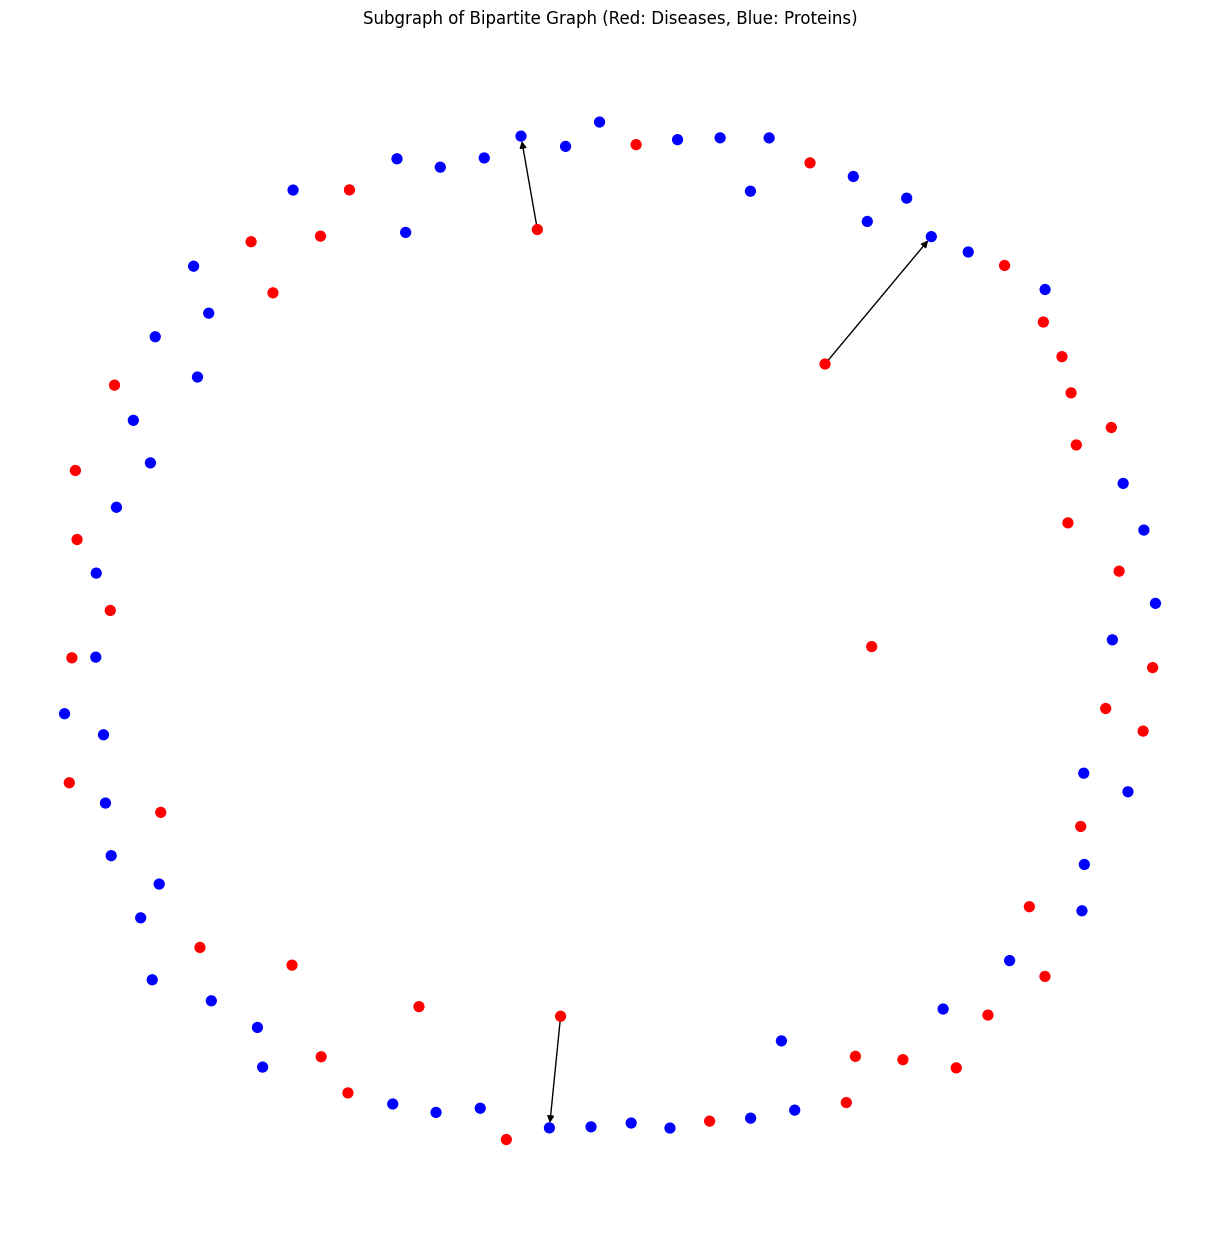

In [78]:
# Visualize the bipartite graph structure (homogeneous, with node coloring)
import networkx as nx
from torch_geometric.utils import to_networkx
import random

# Convert PyG Data to NetworkX
G = to_networkx(bipartite_graph)

# For large graphs, visualize a small subgraph instead
random.seed(42)
subgraph_nodes = random.sample(list(G.nodes()), 100)  # Randomly sample 100 nodes
sub_G = G.subgraph(subgraph_nodes)

# Node colors: red for diseases (0), blue for proteins (1)
node_colors = ['red' if bipartite_graph.node_type[node].item() == 0 else 'blue' for node in sub_G.nodes()]

plt.figure(figsize=(12, 12))
nx.draw(sub_G, node_color=node_colors, node_size=50, with_labels=False)
plt.title('Subgraph of Bipartite Graph (Red: Diseases, Blue: Proteins)')
plt.show()


## Edge Splits

Let's take a look at the edge splits for training, validation, and testing.